In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from scipy.stats import spearmanr, pearsonr


#### Create a label data frame

In [2]:
df_label = pd.read_table('data/mpra_80k_seq_label.tsv.gz', 
                         header=None, 
                         names=["oligo_name", "label"])

In [3]:
df_label["label"].unique()
df_label["label"].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
scramble_ctrl                          500
negative_neuron_ctrl                   451
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    231
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

# NGN2

### MPRA Report label annotation

In [ ]:
df_NGN2 = pd.read_table('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

In [ ]:
df_NGN2.head()

,barcode,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,ACGAGGGGTTTGCTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NaN,NaN,2.0,2.0,1.0,3.0
1,CAGATCGGTTGATTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,5.0,10.0,6.0,5.0,2.0,11.0
2,CTGTTGGTCTATACG,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,1.0,8.0,2.0,3.0,1.0,5.0
3,GATTCGAATGTGTGG,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,5.0,14.0,6.0,14.0,8.0,16.0
4,ACTTAGTTGTCTCTT,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,2.0,2.0,2.0,1.0,1.0,2.0


#### Aggregate NGN2 counts by oligo_name and calculate unique barcode counts

In [ ]:
NGN2_grouped = (
    df_NGN2
    .groupby('oligo_name', as_index=False)
    .agg(
        dna_count_1=('dna_count_1', 'sum'),
        dna_count_2=('dna_count_2', 'sum'),
        dna_count_3=('dna_count_3', 'sum'),
        rna_count_1=('rna_count_1', 'sum'),
        rna_count_2=('rna_count_2', 'sum'),
        rna_count_3=('rna_count_3', 'sum'),
        unique_barcode_count=('barcode', 'nunique')
    )
)

#### Mapping labels to oligo names

In [ ]:
NGN2_grouped['label'] = NGN2_grouped['oligo_name'].map(df_label.set_index('oligo_name')['label'])

# WTC11

In [ ]:
df_WTC11 = pd.read_table('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

#### Aggregate WTC11 counts by oligo_name and calculate unique barcode counts

In [ ]:
WTC11_grouped = df_WTC11.groupby('oligo_name',
                                 as_index = False).agg(
                                     dna_count_1 = ('dna_count_1', 'sum'),
                                     dna_count_2 = ('dna_count_2', 'sum'),
                                     dna_count_3 = ('dna_count_3', 'sum'),
                                     rna_count_1 = ('rna_count_1', 'sum'),
                                     rna_count_2 = ('rna_count_2', 'sum'),
                                     rna_count_3 = ('rna_count_3', 'sum'),
                                     unique_barcode_count = ('barcode', 'nunique')
                                 )                                                             

#### Mapping labels to oligo names

In [ ]:
WTC11_grouped['label'] = WTC11_grouped['oligo_name'].map(df_label.set_index('oligo_name')['label'])

# Comparison of the effect size between NGN2 and WCT11

#### Barcode threshold 10

In [ ]:
df_NGN2_elements_bcalm = pd.read_table('data/results/elements/cli_NGN2_202511_80k_element_bbmap_bcalm_normalized_bc10_toptreat_results_scrambled_NP_MK_result_095_dev.tsv')
df_WTC11_elements_bcalm = pd.read_table('data/results/elements/cli_WTC11_202511_80k_element_bbmap_bcalm_normalized_bc10_toptreat_results_scrambled_NP_MK_result_095_dev.tsv')

#### Barcode threshold 1

In [ ]:
df_WTC11_elements_bcalm_bc_1 = pd.read_table('data/results/elements/bc_1/cli_WTC11_minDNA0_202511_80k_element_bbmap_bcalm_normalized_bc10_toptreat_results_scrambled_NP_MK_result_095_dev.tsv')
WTC11_grouped_bc_1 = WTC11_grouped.copy()

In [ ]:
df_WTC11_elements_bcalm.columns.to_list(), df_WTC11_elements_bcalm_bc_1.columns.to_list()

(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name'],
 ['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name'])

In [ ]:
df_NGN2_elements_bcalm.columns.to_list()

['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name']

In [ ]:
len(df_NGN2_elements_bcalm), len(df_NGN2)

(70479, 6386341)

In [ ]:
len(NGN2_grouped), len(WTC11_grouped)

(77945, 77871)

#### Mapping the effect size to the oligo names, for NGN2 and WTC11 with barcode threshold 10 and 1


In [ ]:
NGN2_grouped['effect_size'] = NGN2_grouped['oligo_name'].map(df_NGN2_elements_bcalm.set_index('name')['logFC'])

In [ ]:
WTC11_grouped['effect_size'] = WTC11_grouped['oligo_name'].map(df_WTC11_elements_bcalm.set_index('name')['logFC'])
WTC11_grouped_bc_1['effect_size'] = WTC11_grouped_bc_1['oligo_name'].map(df_WTC11_elements_bcalm_bc_1.set_index('name')['logFC'])

#### Get scrambled sequences and compute mean and standard deviation, for NGN2 and WTC11 with barcode threshold 10 and 1

In [ ]:
NGN2_grouped_scrambled_mean = NGN2_grouped.loc[NGN2_grouped['label'] == 'scramble_ctrl', 'effect_size'].mean()
NGN2_grouped_scrambled_sd = NGN2_grouped.loc[NGN2_grouped['label'] == 'scramble_ctrl', 'effect_size'].std()

In [ ]:
WTC11_grouped_scrambled_mean = WTC11_grouped.loc[WTC11_grouped['label'] == 'scramble_ctrl', 'effect_size'].mean()
WTC11_grouped_scrambled_sd = WTC11_grouped.loc[WTC11_grouped['label'] == 'scramble_ctrl', 'effect_size'].std()
WTC11_grouped_scrambled_mean_bc_1 = WTC11_grouped_bc_1.loc[WTC11_grouped_bc_1['label'] == 'scramble_ctrl', 'effect_size'].mean()
WTC11_grouped_scrambled_sd_bc_1 = WTC11_grouped_bc_1.loc[WTC11_grouped_bc_1['label'] == 'scramble_ctrl', 'effect_size'].std()

In [ ]:
print(f'NGN2\nThe mean effect size: {NGN2_grouped_scrambled_mean} and the standardeviation: {NGN2_grouped_scrambled_sd} of the scrambled ctrl label')
print(f'WTC11\nThe mean effect size: {WTC11_grouped_scrambled_mean} and the standardeviation: {WTC11_grouped_scrambled_sd} of the scrambled ctrl label')

NGN2
The mean effect size: -0.19105416126572405 and the standardeviation: 0.39332083200077544 of the scrambled ctrl label
WTC11
The mean effect size: -0.037142483586258275 and the standardeviation: 0.3663454379116227 of the scrambled ctrl label


#### Create column with the normalized effect size by using the mean and sd of the scramble_ctrl label data, for NGN2 and WTC11 with barcode threshold 10 and 1

In [ ]:
NGN2_grouped['norm_effect_size'] = (NGN2_grouped['effect_size']-NGN2_grouped_scrambled_mean)/NGN2_grouped_scrambled_sd

In [ ]:
WTC11_grouped['norm_effect_size'] =(WTC11_grouped['effect_size']-WTC11_grouped_scrambled_mean)/WTC11_grouped_scrambled_sd
WTC11_grouped_bc_1['norm_effect_size'] =(WTC11_grouped_bc_1['effect_size']-WTC11_grouped_scrambled_mean_bc_1)/WTC11_grouped_scrambled_sd_bc_1

### Mapping the adjusted p-value to the oligo names, for NGN2 and WTC11 with barcode threshold 10 and 1

In [ ]:
NGN2_grouped['adj.P.Value_NGN2'] = NGN2_grouped['oligo_name'].map(df_NGN2_elements_bcalm.set_index('name')['adj.P.Val'])


In [ ]:
WTC11_grouped['adj.P.Value_WTC11'] = WTC11_grouped['oligo_name'].map(df_WTC11_elements_bcalm.set_index('name')['adj.P.Val'])
WTC11_grouped_bc_1['adj.P.Value_WTC11'] = WTC11_grouped_bc_1['oligo_name'].map(df_WTC11_elements_bcalm_bc_1.set_index('name')['adj.P.Val'])

#### Drop all entries with missing effect size entries

In [ ]:
NGN2_grouped_na_effect_size = NGN2_grouped.dropna(subset = 'effect_size')
WTC11_grouped_na_effect_size = WTC11_grouped.dropna(subset = 'effect_size')
WTC11_grouped_bc_1_na_effect_size = WTC11_grouped_bc_1.dropna(subset = 'effect_size')
print(f'NGN2 grouped size with missing effectsize : {len(NGN2_grouped)}\n'
      f'NGN2 grouped without missing effectsize: {len(NGN2_grouped_na_effect_size)}\n'
      f'WTC11 grouped size with missing effectsize : {len(WTC11_grouped)}\n'
      f'WTC11 grouped without missing effectsize and barcode threshold 10: {len(WTC11_grouped_na_effect_size)}\n'
      f'WTC11 grouped without missing effectsize and barcode threshold 1: {len(WTC11_grouped_bc_1_na_effect_size)}\n')

NGN2 grouped size with missing effectsize : 77945
NGN2 grouped without missing effectsize: 70479
WTC11 grouped size with missing effectsize : 77871
WTC11 grouped without missing effectsize and barcode threshold 10: 53761
WTC11 grouped without missing effectsize and barcode threshold 1: 76206



In [ ]:
print(
    f'NGN2: {len(NGN2_grouped)} total entries. '
    f'After removing entries with missing effect sizes, {len(NGN2_grouped_na_effect_size)} entries remain.\n'
    f'{len(NGN2_grouped) - len(NGN2_grouped_na_effect_size)} entries were removed '
    f'({((len(NGN2_grouped) - len(NGN2_grouped_na_effect_size)) / len(NGN2_grouped)) * 100:.2f}%).'
)

print(
    f'WTC11 bc_10: {len(WTC11_grouped)} total entries. '
    f'After removing entries with missing effect sizes, {len(WTC11_grouped_na_effect_size)} entries remain.\n'
    f'{len(WTC11_grouped) - len(WTC11_grouped_na_effect_size)} entries were removed '
    f'({((len(WTC11_grouped) - len(WTC11_grouped_na_effect_size)) / len(WTC11_grouped)) * 100:.2f}%).'
)

print(
    f'WTC11 bc_1: {len(WTC11_grouped_bc_1)} total entries. '
    f'After removing entries with missing effect sizes, {len(WTC11_grouped_bc_1_na_effect_size)} entries remain.\n'
    f'{len(WTC11_grouped_bc_1) - len(WTC11_grouped_bc_1_na_effect_size)} entries were removed '
    f'({((len(WTC11_grouped_bc_1) - len(WTC11_grouped_bc_1_na_effect_size)) / len(WTC11_grouped_bc_1)) * 100:.2f}%).'
)

NGN2: 77945 total entries. After removing entries with missing effect sizes, 70479 entries remain.
7466 entries were removed (9.58%).
WTC11 bc_10: 77871 total entries. After removing entries with missing effect sizes, 53761 entries remain.
24110 entries were removed (30.96%).
WTC11 bc_1: 77871 total entries. After removing entries with missing effect sizes, 76206 entries remain.
1665 entries were removed (2.14%).


WTC11 with barcode threshold 10 has a substantially higher proportion of missing effect-size values than NGN2 (30.96% vs. 9.58%)

### Analyze the WTC11/NGN2 data with missing and non missing effectsize with a special focus on WTC11

In [ ]:
NGN2_missing = NGN2_grouped[NGN2_grouped['effect_size'].isna()]
NGN2_present = NGN2_grouped[NGN2_grouped['effect_size'].notna()]

In [ ]:
WTC11_missing = WTC11_grouped[WTC11_grouped['effect_size'].isna()]
WTC11_present = WTC11_grouped[WTC11_grouped['effect_size'].notna()]
WTC11_missing_bc_1 = WTC11_grouped_bc_1[WTC11_grouped_bc_1['effect_size'].isna()]
WTC11_present_bc_1 = WTC11_grouped_bc_1[WTC11_grouped_bc_1['effect_size'].notna()]

In [ ]:
WTC11_present[
    ['dna_count_1', 'dna_count_2', 'dna_count_3',
     'rna_count_1', 'rna_count_2', 'rna_count_3']
].describe()

,dna_count_1,dna_count_2,dna_count_3,rna_count_1,rna_count_2,rna_count_3
count,53761.000000,53761.000000,53761.000000,53761.000000,53761.000000,53761.000000
mean,540.754041,557.462212,506.489518,1204.500214,1325.724708,1420.847957
std,342.246724,351.561254,320.712012,942.768554,1027.970120,1103.759507
min,72.000000,63.000000,53.000000,99.000000,119.000000,140.000000
25%,303.000000,314.000000,284.000000,588.000000,652.000000,700.000000
50%,451.000000,465.000000,422.000000,942.000000,1040.000000,1116.000000
75%,682.000000,702.000000,638.000000,1537.000000,1688.000000,1811.000000
max,6426.000000,6203.000000,5608.000000,52228.000000,56367.000000,63721.000000


In [ ]:
WTC11_missing[
    ['dna_count_1', 'dna_count_2', 'dna_count_3',
     'rna_count_1', 'rna_count_2', 'rna_count_3']
].describe()

,dna_count_1,dna_count_2,dna_count_3,rna_count_1,rna_count_2,rna_count_3
count,24110.000000,24110.000000,24110.000000,24110.000000,24110.000000,24110.000000
mean,108.411406,113.154293,102.543509,186.447532,208.730568,226.515595
std,69.686528,72.906019,65.657220,128.448299,142.957229,156.136452
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.000000,56.000000,51.000000,89.000000,100.000000,110.000000
50%,101.000000,106.000000,97.000000,172.000000,192.000000,208.000000
75%,153.000000,160.000000,144.000000,263.000000,296.000000,319.000000
max,510.000000,520.000000,482.000000,2657.000000,3210.000000,3269.000000


In [ ]:
WTC11_present_bc_1[
    ['dna_count_1', 'dna_count_2', 'dna_count_3',
     'rna_count_1', 'rna_count_2', 'rna_count_3']
].describe()

,dna_count_1,dna_count_2,dna_count_3,rna_count_1,rna_count_2,rna_count_3
count,76206.000000,76206.000000,76206.000000,76206.000000,76206.000000,76206.000000
mean,415.406727,428.688253,389.392305,908.212831,1000.736346,1073.382490
std,348.710499,358.287183,326.476206,917.539468,1002.058928,1074.905789
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,167.000000,172.000000,156.000000,293.000000,327.000000,353.000000
50%,326.000000,338.000000,306.000000,639.000000,709.000000,761.000000
75%,567.000000,585.000000,531.000000,1237.000000,1359.000000,1462.000000
max,6426.000000,6203.000000,5608.000000,52228.000000,56367.000000,63721.000000


In [ ]:
WTC11_missing_bc_1[
    ['dna_count_1', 'dna_count_2', 'dna_count_3',
     'rna_count_1', 'rna_count_2', 'rna_count_3']
].describe()

,dna_count_1,dna_count_2,dna_count_3,rna_count_1,rna_count_2,rna_count_3
count,1665.000000,1665.000000,1665.000000,1665.000000,1665.000000,1665.000000
mean,17.292492,17.572973,16.622823,23.494895,25.625225,29.616817
std,21.318083,21.118817,19.888196,26.800906,29.965707,33.182837
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,3.000000,3.000000,3.000000,6.000000
50%,10.000000,11.000000,10.000000,15.000000,17.000000,20.000000
75%,24.000000,24.000000,24.000000,35.000000,37.000000,43.000000
max,175.000000,154.000000,186.000000,221.000000,251.000000,296.000000


#### Count distributions for oligos with and without effect size in WTC11

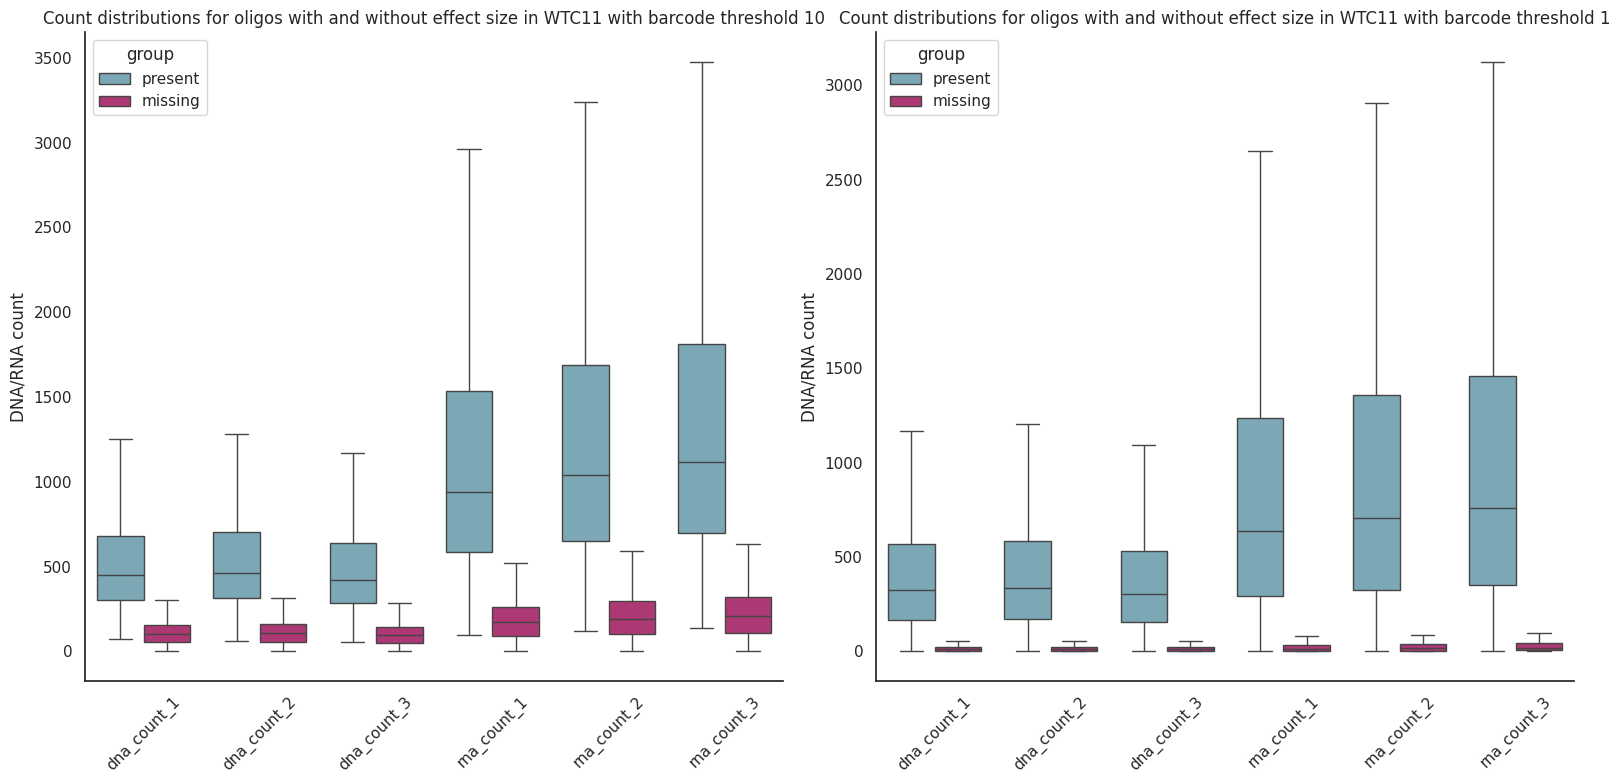

In [ ]:
count_cols = [
    'dna_count_1', 'dna_count_2', 'dna_count_3',
    'rna_count_1', 'rna_count_2', 'rna_count_3'
]

present_long = WTC11_present[count_cols].melt(
    var_name='sample',
    value_name='raw_count'
)
present_long['group'] = 'present'

missing_long = WTC11_missing[count_cols].melt(
    var_name='sample',
    value_name='raw_count'
)
missing_long['group'] = 'missing'

plot_df = pd.concat([present_long, missing_long])

present_long_bc_1 = WTC11_present_bc_1[count_cols].melt(
    var_name='sample',
    value_name='raw_count'
)
present_long_bc_1['group'] = 'present'

missing_long_bc_1 = WTC11_missing_bc_1[count_cols].melt(
    var_name='sample',
    value_name='raw_count'
)
missing_long_bc_1['group'] = 'missing'

plot_df_bc_1 = pd.concat([present_long_bc_1, missing_long_bc_1])


fig, axes = plt.subplots(1,2, figsize = (16,8) )
sns.boxplot(
    data=plot_df,
    x='sample',
    y='raw_count',
    hue='group',
    showfliers=False,
    ax = axes[0]
)

axes[0].tick_params(axis='x', labelrotation=45)
axes[0].set_ylabel('DNA/RNA count')
axes[0].set_xlabel('')
axes[0].set_title('Count distributions for oligos with and without effect size in WTC11 with barcode threshold 10')

sns.boxplot(
    data=plot_df_bc_1,
    x='sample',
    y='raw_count',
    hue='group',
    showfliers=False,
    ax = axes[1]
)

axes[1].tick_params(axis='x', labelrotation=45)
axes[1].set_ylabel('DNA/RNA count')
axes[1].set_xlabel('')
axes[1].set_title('Count distributions for oligos with and without effect size in WTC11 with barcode threshold 1')

plt.tight_layout()
plt.show()

### Correlation of the effectsize between WTC11 with barcode threshold 10 and 1

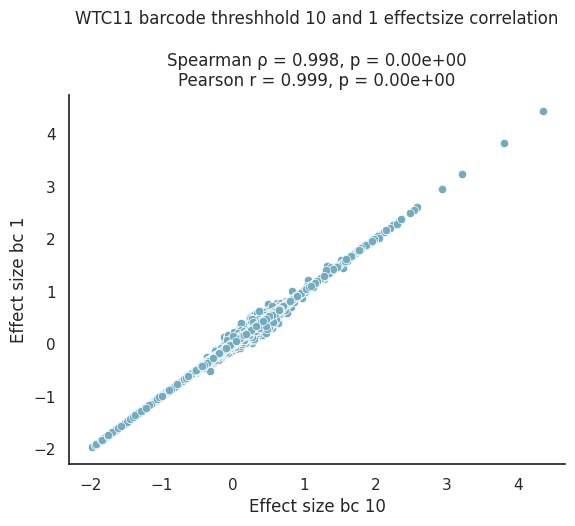

Spearman rho: 0.998, p = 0.000e+00
Pearson r:    0.999, p = 0.000e+00


In [ ]:
WTC11_effectsize_complete = WTC11_grouped[['oligo_name', 'effect_size']].merge(right = WTC11_grouped_bc_1[['oligo_name', 'effect_size']],
                                                on = 'oligo_name',
                                                how = 'outer',
                                                suffixes = ('_bc10', '_bc1'))
WTC11_effectsize_correlation = WTC11_effectsize_complete.dropna(
    subset=['effect_size_bc10', 'effect_size_bc1']
)
# Spearman correlation
spearman_r, spearman_p = spearmanr(
    WTC11_effectsize_correlation['effect_size_bc10'],
    WTC11_effectsize_correlation['effect_size_bc1']
)

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    WTC11_effectsize_correlation['effect_size_bc10'],
    WTC11_effectsize_correlation['effect_size_bc1']
)

# Plot
sns.scatterplot(
    data=WTC11_effectsize_correlation,
    x='effect_size_bc10',
    y='effect_size_bc1'
)

plt.title(
    f'WTC11 barcode threshhold 10 and 1 effectsize correlation\n\n'
    f'Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.2e}\n'
    f'Pearson r = {pearson_r:.3f}, p = {pearson_p:.2e}'
)

plt.xlabel('Effect size bc 10')
plt.ylabel('Effect size bc 1')

plt.show()

print(f"Spearman rho: {spearman_r:.3f}, p = {spearman_p:.3e}")
print(f"Pearson r:    {pearson_r:.3f}, p = {pearson_p:.3e}")

### Assign the barcodes to the oligos to find out why WTC11 has so much entries without effect size and NGN2 so much more

#### Create Data Frame with the barcode assignment data

In [ ]:
assignment = pd.read_table('data/assignment_barcodes.default.tsv.gz',
                           header = None,
                           names = ["barcode", "oligo_name"])

In [ ]:
assignment

,barcode,oligo_name
0,AAAAAAAAAAACGTC,GC_Vista:eye;fb;hb;mb_hs1644_vistaElementContr...
1,AAAAAAAAAACAAGT,cardiac_neuro_cava_random:ALT_ZBTB20|ENSG00000...
2,AAAAAAAAAACACCA,cardiac_neuro_cava_random:ALT_FTO|ENSG00000140...
3,AAAAAAAAAACCTCG,cardiac_neuro_cava_random:REF_FKRP|ENSG0000018...
4,AAAAAAAAAAGCTGG,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
...,...,...
7373977,TTTTTTTTTTGACGA,cardiac_neuro_cava_random:ALT_ACTN2|ENSG000000...
7373978,TTTTTTTTTTGCACA,cardiac_neuro_cava_random:ALT_CARD11|ENSG00000...
7373979,TTTTTTTTTTGCACC,cardiac_neuro_cava_random:ALT_KRAS|ENSG0000013...
7373980,TTTTTTTTTTGCTAA,cardiac_neuro_cava_random:REF_NR4A2|ENSG000001...


In [ ]:
assignment["barcode"].nunique()

7373982

In [ ]:
barcode_per_oligo = (
    assignment
    .groupby("oligo_name")["barcode"]
    .nunique()
    .reset_index(name="n_assigned_barcodes")
)

### Merge WTC11/NGN2 oligos with and without effect size with the number of assigned barcodes

#### Barcode threshold 10

In [ ]:
WTC11_missing_bc = WTC11_missing.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)
WTC11_present_bc = WTC11_present.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)

In [ ]:
NGN2_missing_bc = NGN2_missing.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)
NGN2_present_bc = NGN2_present.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)

#### Barcode threshold 1

In [ ]:
WTC11_missing_bc_1 = WTC11_missing_bc_1.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)
WTC11_present_bc_1 = WTC11_present_bc_1.merge(
    barcode_per_oligo,
    on="oligo_name",
    how="left"
)

In [ ]:
NGN2_missing_bc["n_assigned_barcodes"] = (
    NGN2_missing_bc["n_assigned_barcodes"].fillna(0)
)

NGN2_present_bc["n_assigned_barcodes"] = (
    NGN2_present_bc["n_assigned_barcodes"].fillna(0)
)

In [ ]:
WTC11_missing_bc["n_assigned_barcodes"] = (
    WTC11_missing_bc["n_assigned_barcodes"].fillna(0)
)

WTC11_present_bc["n_assigned_barcodes"] = (
    WTC11_present_bc["n_assigned_barcodes"].fillna(0)
)

WTC11_missing_bc_1["n_assigned_barcodes"] = (
    WTC11_missing_bc_1["n_assigned_barcodes"].fillna(0)
)

WTC11_present_bc_1["n_assigned_barcodes"] = (
    WTC11_present_bc_1["n_assigned_barcodes"].fillna(0)
)

#### Comparison of assigned barcode distributions in WTC11/NGN2 oligos with and without effect size

In [ ]:
print('Barcode count threshold 10')
print("Missing effect size")
print(NGN2_missing_bc["n_assigned_barcodes"].describe())

print("\nPresent effect size")
print(NGN2_present_bc["n_assigned_barcodes"].describe())

Barcode count threshold 10
Missing effect size
count    7466.000000
mean       11.975757
std        11.107974
min         1.000000
25%         5.000000
50%        10.000000
75%        15.000000
max       199.000000
Name: n_assigned_barcodes, dtype: float64

Present effect size
count    70479.000000
mean       103.356617
std         69.391337
min         10.000000
25%         52.000000
50%         89.000000
75%        137.000000
max       1084.000000
Name: n_assigned_barcodes, dtype: float64


In [ ]:
print('Barcode count threshold 10')
print("Missing effect size")
print(WTC11_missing_bc["n_assigned_barcodes"].describe())

print("\nPresent effect size")
print(WTC11_present_bc["n_assigned_barcodes"].describe())

print('\nBarcode count threshold 1')
print("Missing effect size")
print(WTC11_missing_bc_1["n_assigned_barcodes"].describe())

print("\nPresent effect size")
print(WTC11_present_bc_1["n_assigned_barcodes"].describe())

Barcode count threshold 10
Missing effect size
count    24110.000000
mean        36.046122
std         30.846973
min          1.000000
25%         15.000000
50%         28.000000
75%         47.000000
max        302.000000
Name: n_assigned_barcodes, dtype: float64

Present effect size
count    53761.000000
mean       120.993099
std         68.595651
min         12.000000
25%         72.000000
50%        107.000000
75%        153.000000
max       1084.000000
Name: n_assigned_barcodes, dtype: float64

Barcode count threshold 1
Missing effect size
count    1665.000000
mean        9.554354
std        13.816520
min         1.000000
25%         2.000000
50%         5.000000
75%        12.000000
max       199.000000
Name: n_assigned_barcodes, dtype: float64

Present effect size
count    76206.000000
mean        96.552424
std         70.927233
min          1.000000
25%         44.000000
50%         82.000000
75%        132.000000
max       1084.000000
Name: n_assigned_barcodes, dtype: float64


In [ ]:
NGN2_missing_bc_plot = NGN2_missing_bc[['n_assigned_barcodes']].copy()
NGN2_missing_bc_plot['effect_size_status'] = 'Without effect size'

NGN2_present_bc_plot = NGN2_present_bc[['n_assigned_barcodes']].copy()
NGN2_present_bc_plot['effect_size_status'] = 'With effect size'

NGN2_bc_plot = pd.concat([
    NGN2_missing_bc_plot,
    NGN2_present_bc_plot
])

In [ ]:
WTC11_missing_bc_plot = WTC11_missing_bc[['n_assigned_barcodes']].copy()
WTC11_missing_bc_plot['effect_size_status'] = 'Without effect size'

WTC11_present_bc_plot = WTC11_present_bc[['n_assigned_barcodes']].copy()
WTC11_present_bc_plot['effect_size_status'] = 'With effect size'

WTC11_bc_plot = pd.concat([
    WTC11_missing_bc_plot,
    WTC11_present_bc_plot
])

WTC11_missing_bc_plot_bc_1 = WTC11_missing_bc_1[['n_assigned_barcodes']].copy()
WTC11_missing_bc_plot_bc_1['effect_size_status'] = 'Without effect size'

WTC11_present_bc_plot_bc_1 = WTC11_present_bc_1[['n_assigned_barcodes']].copy()
WTC11_present_bc_plot_bc_1['effect_size_status'] = 'With effect size'

WTC11_bc_plot_bc_1 = pd.concat([
    WTC11_missing_bc_plot_bc_1,
    WTC11_present_bc_plot_bc_1
])

#### Merge NGN2 and WTC11 for the violin plot

In [ ]:
NGN2_bc_plot['dataset'] = 'NGN2'
WTC11_bc_plot['dataset'] = 'WTC11'

NGN2_WTC11_compare = pd.concat([
 NGN2_bc_plot,
 WTC11_bc_plot
   
])

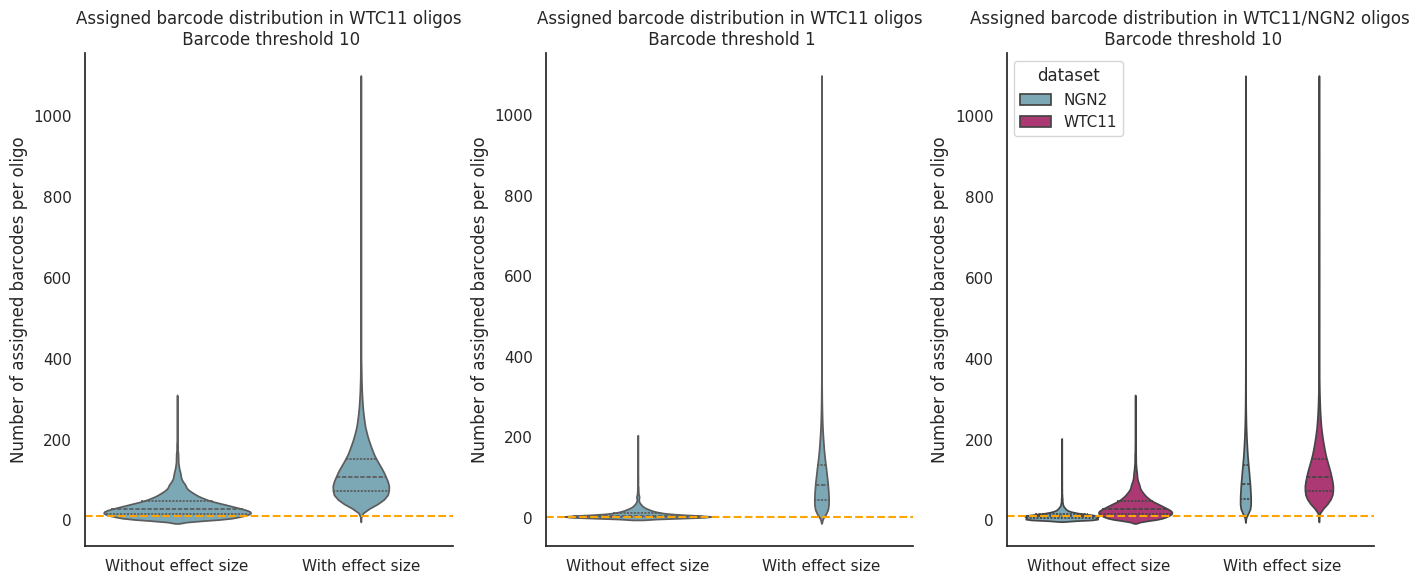

In [ ]:
fig, axes = plt.subplots(1,3, figsize = (14,6))

sns.violinplot(
    data=WTC11_bc_plot,
    x='effect_size_status',
    y='n_assigned_barcodes',
    inner='quartile',
    ax = axes[0]
)

axes[0].axhline(y = 10,
            color = 'orange',
            linestyle = '--')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of assigned barcodes per oligo')
axes[0].set_title('Assigned barcode distribution in WTC11 oligos\n Barcode threshold 10')

sns.violinplot(
    data=WTC11_bc_plot_bc_1,
    x='effect_size_status',
    y='n_assigned_barcodes',
    inner='quartile',
    ax = axes[1]
)

axes[1].axhline(y = 1,
            color = 'orange',
            linestyle = '--')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of assigned barcodes per oligo')
axes[1].set_title('Assigned barcode distribution in WTC11 oligos\n Barcode threshold 1')

sns.violinplot(
    data= NGN2_WTC11_compare,
    x='effect_size_status',
    y='n_assigned_barcodes',
    inner='quartile',
    hue = 'dataset',
    #density_norm='count',
    ax = axes[2]
)

axes[2].axhline(y = 10,
            color = 'orange',
            linestyle = '--')
axes[2].set_xlabel('')
axes[2].set_ylabel('Number of assigned barcodes per oligo')
axes[2].set_title('Assigned barcode distribution in WTC11/NGN2 oligos\n Barcode threshold 10')



plt.tight_layout()
plt.show()

### Barcode distribution of complet NGN2 and WTC11

In [ ]:
print("Threshold 10:")
print(WTC11_bc_plot['effect_size_status'].value_counts())

print("\nThreshold 1:")
print(WTC11_bc_plot_bc_1['effect_size_status'].value_counts())

Threshold 10:
effect_size_status
With effect size       53761
Without effect size    24110
Name: count, dtype: int64

Threshold 1:
effect_size_status
With effect size       76206
Without effect size     1665
Name: count, dtype: int64


### Merge NGN2 and WTC11 tabels

#### Barcode threshold 10

In [ ]:
NGN2_WTC11_merge = NGN2_grouped_na_effect_size.merge(right = WTC11_grouped_na_effect_size,
                   how = 'inner',
                   on = 'oligo_name',
                   suffixes = ('_NGN2', '_WTC11')
                   )
NGN2_WTC11_merge.drop('label_NGN2',
                      inplace = True,
                      axis = 1)
NGN2_WTC11_merge.rename(columns = {'label_WTC11': 'label'},
                        inplace = True)
NGN2_WTC11_merge.columns.to_list()

['oligo_name',
 'dna_count_1_NGN2',
 'dna_count_2_NGN2',
 'dna_count_3_NGN2',
 'rna_count_1_NGN2',
 'rna_count_2_NGN2',
 'rna_count_3_NGN2',
 'unique_barcode_count_NGN2',
 'effect_size_NGN2',
 'norm_effect_size_NGN2',
 'adj.P.Value_NGN2',
 'dna_count_1_WTC11',
 'dna_count_2_WTC11',
 'dna_count_3_WTC11',
 'rna_count_1_WTC11',
 'rna_count_2_WTC11',
 'rna_count_3_WTC11',
 'unique_barcode_count_WTC11',
 'label',
 'effect_size_WTC11',
 'norm_effect_size_WTC11',
 'adj.P.Value_WTC11']

### Barcode threshold 10 !!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
NGN2_WTC11_merge = NGN2_grouped_na_effect_size.merge(right = WTC11_grouped_na_effect_size,
                   how = 'inner',
                   on = 'oligo_name',
                   suffixes = ('_NGN2', '_WTC11')
                   )
NGN2_WTC11_merge.drop('label_NGN2',
                      inplace = True,
                      axis = 1)
NGN2_WTC11_merge.rename(columns = {'label_WTC11': 'label'},
                        inplace = True)
NGN2_WTC11_merge.columns.to_list()

['oligo_name',
 'dna_count_1_NGN2',
 'dna_count_2_NGN2',
 'dna_count_3_NGN2',
 'rna_count_1_NGN2',
 'rna_count_2_NGN2',
 'rna_count_3_NGN2',
 'unique_barcode_count_NGN2',
 'effect_size_NGN2',
 'norm_effect_size_NGN2',
 'adj.P.Value_NGN2',
 'dna_count_1_WTC11',
 'dna_count_2_WTC11',
 'dna_count_3_WTC11',
 'rna_count_1_WTC11',
 'rna_count_2_WTC11',
 'rna_count_3_WTC11',
 'unique_barcode_count_WTC11',
 'label',
 'effect_size_WTC11',
 'norm_effect_size_WTC11',
 'adj.P.Value_WTC11']

#### Comparing the unique oligos per cell type with the merged data table

In [ ]:
print(f'Number of unique oligos in NGN2: {len(NGN2_grouped_na_effect_size)}\nNumber of unique oligos in WTC11: {len(WTC11_grouped_na_effect_size)}\nNumber of unique oligos in the merged data table: {len(NGN2_WTC11_merge)}')
print(f'Percentage of NGN2 oligos retained after merging: {len(NGN2_WTC11_merge) / len(NGN2_grouped_na_effect_size) * 100:.3f}%')
print(f'Percentage of WTC11 oligos retained after merging: {len(NGN2_WTC11_merge) / len(WTC11_grouped_na_effect_size) * 100:.3f}%')

Number of unique oligos in NGN2: 70479
Number of unique oligos in WTC11: 53761
Number of unique oligos in the merged data table: 53760
Percentage of NGN2 oligos retained after merging: 76.278%
Percentage of WTC11 oligos retained after merging: 99.998%


### Venn diagram to show the overlapping effect size

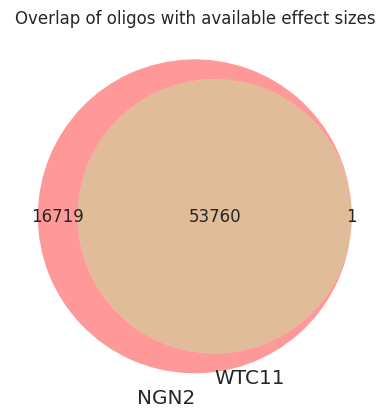

In [ ]:
venn2(subsets = [set(NGN2_grouped_na_effect_size['oligo_name']), set(WTC11_grouped_na_effect_size['oligo_name'])],
      set_labels = ('NGN2', 'WTC11'))

plt.title('Overlap of oligos with available effect sizes')
plt.show()

#### Effect size with all labels for the NGN2 and WTC11 cells

In [ ]:
NGN2_WTC11_effect_size_distribution = NGN2_WTC11_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['norm_effect_size_NGN2', 'norm_effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)

NGN2_WTC11_effect_size_distribution.loc[NGN2_WTC11_effect_size_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
NGN2_WTC11_effect_size_distribution.loc[NGN2_WTC11_effect_size_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

#### Save the element data for comparison with the variant data

In [ ]:
NGN2_WTC11_merge.to_csv('data/results/merge_elements/element_merge.tsv',
                        sep = '\t',
                        index = False)

Plotting barcode distribution

In [ ]:
NGN2_WTC11_merge

,oligo_name,dna_count_1_NGN2,dna_count_2_NGN2,dna_count_3_NGN2,rna_count_1_NGN2,rna_count_2_NGN2,rna_count_3_NGN2,unique_barcode_count_NGN2,effect_size_NGN2,norm_effect_size_NGN2,...,dna_count_2_WTC11,dna_count_3_WTC11,rna_count_1_WTC11,rna_count_2_WTC11,rna_count_3_WTC11,unique_barcode_count_WTC11,label,effect_size_WTC11,norm_effect_size_WTC11,adj.P.Value_WTC11
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,537.0,509.0,538.0,1536.0,1465.0,1567.0,151,0.009842,0.510769,...,965.0,755.0,1938.0,2189.0,2279.0,141,C_SLEA,0.193683,0.630077,1.0
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,478.0,559.0,597.0,3122.0,2489.0,3020.0,131,0.891777,2.753048,...,852.0,671.0,2290.0,2451.0,2540.0,121,C_SLEA,0.453775,1.340039,1.0
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,334.0,294.0,336.0,1009.0,1005.0,966.0,99,0.092969,0.722116,...,448.0,494.0,1041.0,1162.0,1136.0,87,C_SLEA,-0.093951,-0.155068,1.0
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,400.0,467.0,497.0,1356.0,1328.0,1301.0,121,0.024602,0.548297,...,898.0,700.0,1713.0,2027.0,2070.0,120,C_SLEA,0.012860,0.136489,1.0
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,261.0,269.0,300.0,841.0,816.0,855.0,68,0.092226,0.720226,...,478.0,440.0,1001.0,1065.0,1184.0,64,C_SLEA,0.252162,0.789705,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53755,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,334.0,318.0,345.0,920.0,969.0,877.0,105,-0.032915,0.402061,...,558.0,397.0,957.0,1183.0,1231.0,89,cardiac_neuro_cava_random,0.152485,0.517619,1.0
53756,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,200.0,178.0,193.0,586.0,581.0,561.0,56,-0.012162,0.454826,...,249.0,361.0,882.0,791.0,947.0,52,cardiac_neuro_cava_random,0.320574,0.976447,1.0
53757,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,300.0,334.0,315.0,1890.0,1504.0,1839.0,115,0.969816,2.951458,...,570.0,404.0,864.0,1157.0,1096.0,101,cardiac_neuro_cava_random,-0.278136,-0.657831,1.0
53758,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,97.0,79.0,112.0,389.0,358.0,390.0,38,0.617933,2.056813,...,157.0,217.0,277.0,377.0,515.0,30,cardiac_neuro_cava_random,0.181087,0.595692,1.0


In [ ]:
NGN2_WTC11_merge["effect_size_NGN2"].isna().sum()

np.int64(0)

In [ ]:
NGN2_WTC11_barcode_count_distribution = NGN2_WTC11_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['unique_barcode_count_NGN2', 'unique_barcode_count_WTC11'],
    var_name = 'celltype',
    value_name = 'barcode_count'
)
NGN2_WTC11_barcode_count_distribution

,oligo_name,celltype,barcode_count
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,unique_barcode_count_NGN2,151
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,unique_barcode_count_NGN2,131
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,99
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,121
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,unique_barcode_count_NGN2,68
...,...,...,...
107515,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,89
107516,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,52
107517,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,101
107518,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,unique_barcode_count_WTC11,30


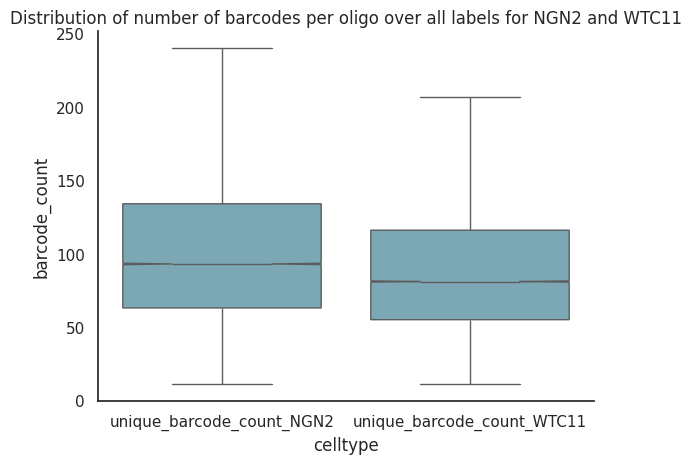

In [ ]:
sns.boxplot(data = NGN2_WTC11_barcode_count_distribution,
               x = 'celltype',
               y = 'barcode_count',
               showfliers=False,
               notch=True)
# TODO: add statistical test to compare mean difference with p-value and add the stars wie z.b.: https://www.researchgate.net/figure/A-box-plot-visualization-including-Mann-Whitney-U-tests-of-the-sarcopenia-and-cardiac_fig3_364058085
plt.title('Distribution of number of barcodes per oligo over all labels for NGN2 and WTC11')
plt.show()

### Ploting the distribution of the normalized effectsize over all labels for the NGN2 and WTC11 celltypes

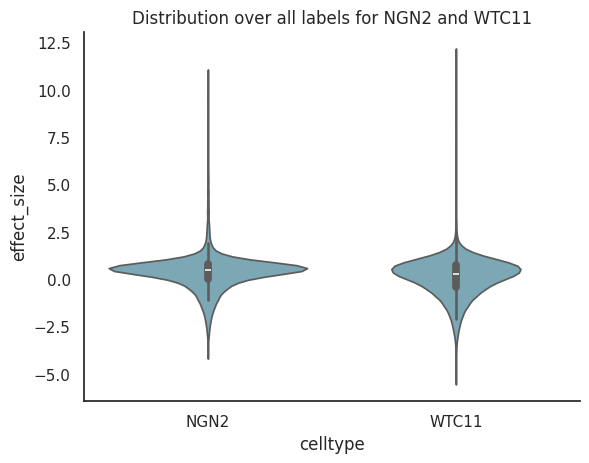

In [ ]:
sns.violinplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'effect_size')
plt.title('Distribution over all labels for NGN2 and WTC11')
plt.show()

In [ ]:
NGN2_WTC11_effect_size_distribution["abs_effect_size"] = NGN2_WTC11_effect_size_distribution["effect_size"].abs()

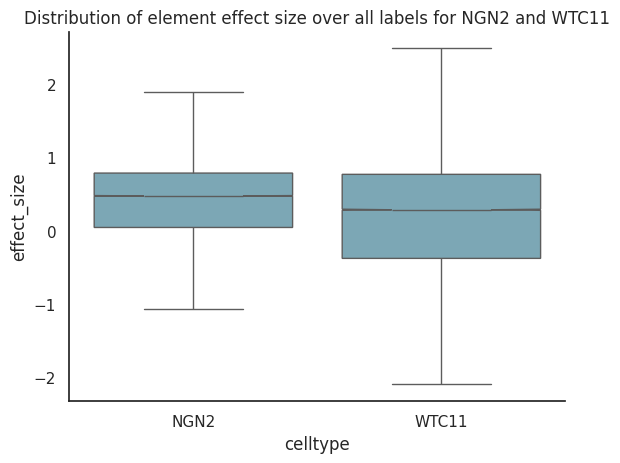

In [ ]:
sns.boxplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'effect_size',
               showfliers=False,
               notch=True)
plt.title('Distribution of element effect size over all labels for NGN2 and WTC11')
plt.show()

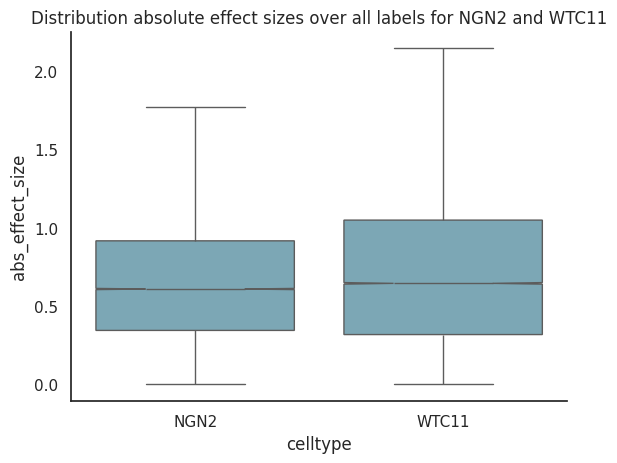

In [ ]:
sns.boxplot(data = NGN2_WTC11_effect_size_distribution,
               x = 'celltype',
               y = 'abs_effect_size',
               showfliers=False,
               notch=True)
plt.title('Distribution absolute effect sizes over all labels for NGN2 and WTC11')
plt.show()

# Scramble_ctrl

#### Create data frames only für the scramble_ctrl labels

In [ ]:
merge_scrambled = NGN2_WTC11_merge[NGN2_WTC11_merge['label'] == 'scramble_ctrl']

### Spearman plot for the effect size of the merged table

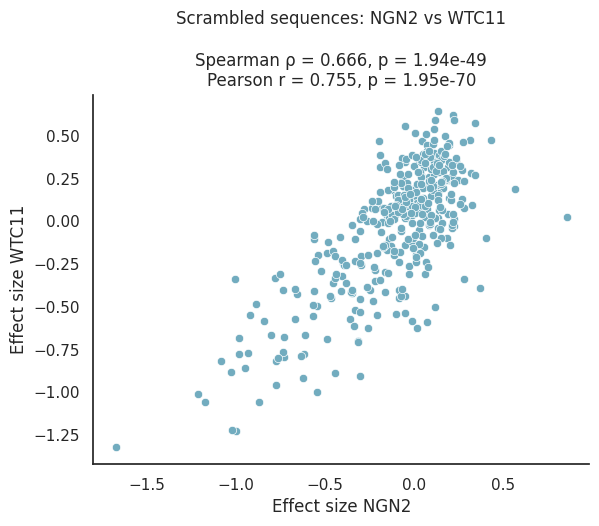

Spearman rho: 0.666, p = 1.935e-49
Pearson r:    0.755, p = 1.954e-70


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# Spearman correlation
spearman_r, spearman_p = spearmanr(
    merge_scrambled['effect_size_NGN2'],
    merge_scrambled['effect_size_WTC11']
)

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    merge_scrambled['effect_size_NGN2'],
    merge_scrambled['effect_size_WTC11']
)

# Plot
sns.scatterplot(
    data=merge_scrambled,
    x='effect_size_NGN2',
    y='effect_size_WTC11'
)

plt.title(
    f'Scrambled sequences: NGN2 vs WTC11\n\n'
    f'Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.2e}\n'
    f'Pearson r = {pearson_r:.3f}, p = {pearson_p:.2e}'
)

plt.xlabel('Effect size NGN2')
plt.ylabel('Effect size WTC11')

plt.show()

print(f"Spearman rho: {spearman_r:.3f}, p = {spearman_p:.3e}")
print(f"Pearson r:    {pearson_r:.3f}, p = {pearson_p:.3e}")

The effect sizes of scrambled control oligos show a strong positive correlation between NGN2 and WTC11 (Spearman ρ = 0.666, Pearson r = 0.755), with both correlations being highly statistically significant. The slightly higher Pearson correlation is consistent with a strong linear relationship between the effect sizes

### Violin plot to show the distribution of the effect size between the NGN2 and WTC11 cells

In [ ]:
merge_scrambled_long = merge_scrambled.melt(
    id_vars = 'oligo_name',
    value_vars = ['effect_size_NGN2', 'effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)
merge_scrambled_long.loc[merge_scrambled_long['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
merge_scrambled_long.loc[merge_scrambled_long['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

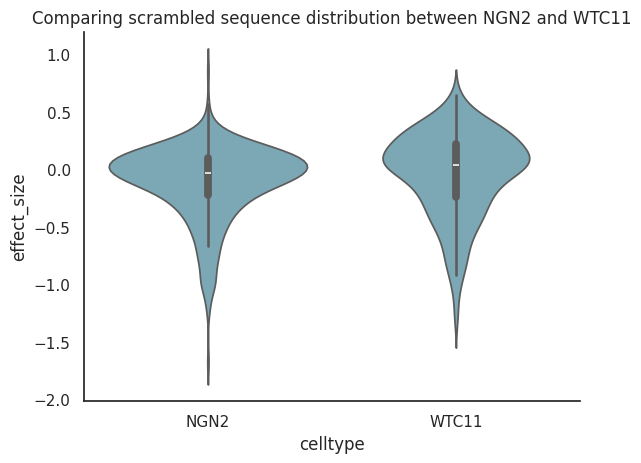

In [ ]:
sns.violinplot(data = merge_scrambled_long,
               x = 'celltype',
               y = 'effect_size',
)
plt.title('Comparing scrambled sequence distribution between NGN2 and WTC11')
plt.show()



# Distribution of unique barcode count in cardiac_neuro_cava for both cell types

#### Filter for cardiac neuro cava random label

In [ ]:
cardiac_merge = NGN2_WTC11_merge[NGN2_WTC11_merge['label'] == 'cardiac_neuro_cava_random'].reset_index(drop = True)

#### Create a long-format data table assigning unique barcode counts to each cell type

In [ ]:
barcode_distribution = cardiac_merge.melt(
    id_vars = 'oligo_name',
    value_vars = ['unique_barcode_count_NGN2', 'unique_barcode_count_WTC11'],
    var_name = 'celltype',
    value_name = 'unique_barcode_count'
)
barcode_distribution.loc[barcode_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2'
barcode_distribution.loc[barcode_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11'

#### Plot the unique barcode count distribution

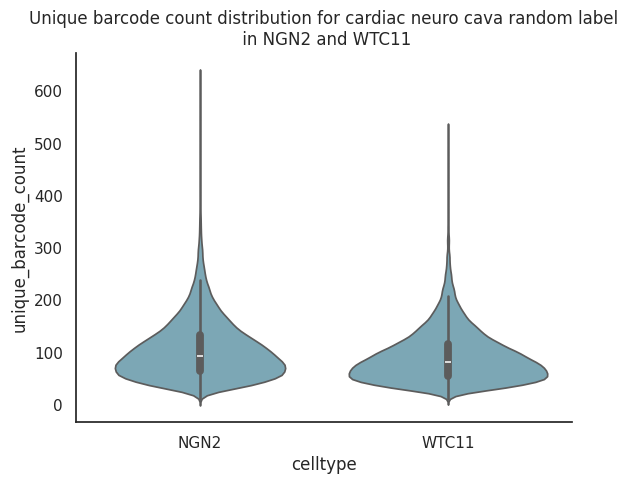

In [ ]:
sns.violinplot(data = barcode_distribution,
               x = 'celltype',
               y = 'unique_barcode_count')
plt.title('Unique barcode count distribution for cardiac neuro cava random label\n in NGN2 and WTC11')
plt.show()

# Scramble_ctrl combined with cardiac_neuro_cava_random

#### Filter for Scramble_ctrl and cardiac neuro cava label

In [ ]:
scramble_cardiac_merge = NGN2_WTC11_merge[NGN2_WTC11_merge['label'].isin(['scramble_ctrl',
                                                                          'cardiac_neuro_cava_random'])]

In [ ]:
scramble_cardiac_distribution = scramble_cardiac_merge.melt(
    id_vars = 'label',
    value_vars = ['norm_effect_size_NGN2', 'norm_effect_size_WTC11'],
    var_name = 'celltype',
    value_name = 'effect_size'
)
scramble_cardiac_distribution.loc[scramble_cardiac_distribution['celltype'].str.contains('NGN2'), 'celltype'] = 'NGN2' 
scramble_cardiac_distribution.loc[scramble_cardiac_distribution['celltype'].str.contains('WTC11'), 'celltype'] = 'WTC11' 

#### Create a violin plot to compare the normalized effect size of both cell types with the scrambled_ctr and cardiac_neuro_cava_random lables

<Axes: xlabel='celltype', ylabel='effect_size'>

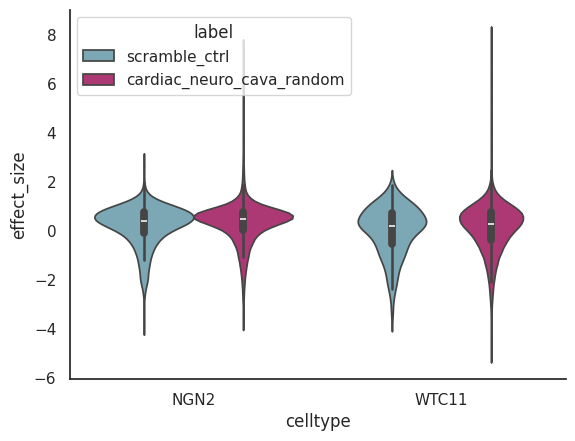

In [ ]:
sns.violinplot(data = scramble_cardiac_distribution,
               x = 'celltype',
               y = 'effect_size',
               hue = 'label')